# 1. Preparation

## 1.1 Prepare environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!pip install torchinfo

In [3]:
import sys
print( f"Python {sys.version}\n" )

import random
import time

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

import torchinfo
print( f"torchinfo {torchinfo.__version__}" )
import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")

        # Important: The CUDA version in "nvidia-smi" must be equal or higher than "torch.version.cuda".
        # If they mismatch, it may cause silent hangs during heavy CUDA operations.
        # In that case, reinstall PyTorch from pytorch.org with the correct CUDA version.
        print(f"   |- {torch.version.cuda = }")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

NumPy 2.0.2

torchinfo 1.8.0
PyTorch 2.11.0+cpu
|- No hardware accelerators found. Using CPU only.


## 1.2 Prepare global variables/functions

In [4]:
# Reproducibility & Device Configuration
def set_seeds(seed=42):
    """Sets fixed seeds for reproducibility across all libraries."""
    random.seed(seed)         # Controls Python's built-in random numbers.
    np.random.seed(seed)      # Controls NumPy's random arrays.
    torch.manual_seed(seed)           # Controls CPU weight initialization.
    torch.cuda.manual_seed_all(seed)  # Controls GPU weight initialization.

    # Ensure deterministic behavior for some PyTorch operations
    # This often comes with a performance cost, since it disables cuDNN's autotuning that picks the fastest algorithm for their hardware
    torch.backends.cudnn.deterministic = True # Ensure the GPU doesn't use "fast but slightly random" algorithms for math
    torch.backends.cudnn.benchmark = False
    print(f"Seeds set to {seed} for reproducibility.")

set_seeds(42)

Seeds set to 42 for reproducibility.


In [5]:
# Detect GPU (CUDA), Apple Silicon (MPS), or fallback to CPU
# 'device' is a scalar flag, not a tensor
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 2. Prepare the data

Dataset generation:

- Suppose that this example deals with the single-label multi-class classification problem where a single input is a 1D vector of shape (100,) and there are 10 predefined classes of output.

In [6]:
input_dim = 100     # The number of features per one input
output_dim = 10     # The number of output classes

trainval_size = 10000    # train set + validation set
test_size = 2000         # test set

In [7]:
# Data generated after seeding will now be deterministic
# Seeding fixes the entire sequence, not just the first call
x_trainval = np.random.randn(trainval_size, input_dim)
y_trainval = np.random.randint(0, output_dim, trainval_size)
x_test = np.random.randn(test_size, input_dim)
y_test = np.random.randint(0, output_dim, test_size)

print( f"x_trainval.shape={x_trainval.shape} , x_trainval.dtype={x_trainval.dtype} , min(x_trainval)={np.min(x_trainval):.4f} , max(x_trainval)={np.max(x_trainval):.4f}" )
print( f"y_trainval.shape={y_trainval.shape} , y_trainval.dtype={y_trainval.dtype} , min(y_trainval)={np.min(y_trainval)} , max(y_trainval)={np.max(y_trainval)}" )
print( f"x_test.shape={x_test.shape} , x_test.dtype={x_test.dtype} , min(x_test)={np.min(x_test):.4f} , max(x_test)={np.max(x_test):.4f}" )
print( f"y_test.shape={y_test.shape} , y_test.dtype={y_test.dtype} , min(y_test)={np.min(y_test)} , max(y_test)={np.max(y_test)}" )

x_trainval.shape=(10000, 100) , x_trainval.dtype=float64 , min(x_trainval)=-4.8294 , max(x_trainval)=4.6789
y_trainval.shape=(10000,) , y_trainval.dtype=int64 , min(y_trainval)=0 , max(y_trainval)=9
x_test.shape=(2000, 100) , x_test.dtype=float64 , min(x_test)=-4.6444 , max(x_test)=4.5958
y_test.shape=(2000,) , y_test.dtype=int64 , min(y_test)=0 , max(y_test)=9


Manual data preprocessing:

In [8]:
# Convert to tensors
x_trainval_tensor = torch.tensor(x_trainval, dtype=torch.float32)
y_trainval_tensor = torch.tensor(y_trainval, dtype=torch.long)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create the full training dataset (train+val)
trainval_dataset = torch.utils.data.TensorDataset(x_trainval_tensor, y_trainval_tensor)

# Define split sizes (e.g., 80% train, 20% validation)
train_size = int(0.8 * trainval_size)
val_size = trainval_size - train_size

# Use random_split to create two subsets
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [train_size, val_size])

# Create the test dataset
test_dataset = torch.utils.data.TensorDataset(x_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)  # Shuffle only for training
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)     # Never shuffle validation/test
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)   # Never shuffle validation/test

# 3. Create the network architecture

In [9]:
model = torch.nn.Sequential(
            # --- Three hidden layers ---
            # 1. Hidden layer
            torch.nn.Linear(input_dim, 256),
            torch.nn.ReLU(),

            # 2. Hidden layer
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),

            # 3. Hidden layer
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),

            # --- Output layer ---
            torch.nn.Linear(64, output_dim)  # output logits -> [bs, output_dim]
        )

In [10]:
# CRITICAL: Move model to device (Initialization happens here)
model = model.to(device)

# CHECKING MODEL DEVICE
# - In PyTorch, models don't have a single .device attribute, but their parameters do.
model_device = next(model.parameters()).device
print(f"Model is currently on: {model_device}")

Model is currently on: cpu


Manual model inspection:

In [11]:
print("--- Model Text Summary ---")
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Trainable Parameters: {total_params:,}")

--- Model Text Summary ---
Sequential(
  (0): Linear(in_features=100, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=10, bias=True)
)
Total Trainable Parameters: 67,658


In [12]:
# Monitor weights of the first layer
first_layer_weights = model[0].weight.data
print(first_layer_weights.shape)
print(first_layer_weights)

torch.Size([256, 100])
tensor([[-0.0178,  0.0541, -0.0831,  ...,  0.0235,  0.0822,  0.0888],
        [-0.0258,  0.0149, -0.0668,  ...,  0.0917,  0.0350, -0.0560],
        [ 0.0757,  0.0928, -0.0271,  ...,  0.0235,  0.0034,  0.0219],
        ...,
        [-0.0803, -0.0172, -0.0612,  ..., -0.0426,  0.0862,  0.0860],
        [ 0.0911,  0.0837,  0.0984,  ..., -0.0170, -0.0685,  0.0313],
        [ 0.0730, -0.0859, -0.0973,  ...,  0.0104, -0.0383,  0.0473]])


Print model summary by `torchinfo`:

In [13]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Linear: 1-1                            25,856
├─ReLU: 1-2                              --
├─Linear: 1-3                            32,896
├─ReLU: 1-4                              --
├─Linear: 1-5                            8,256
├─ReLU: 1-6                              --
├─Linear: 1-7                            650
Total params: 67,658
Trainable params: 67,658
Non-trainable params: 0

# 4. Train the model

In [14]:
# CrossEntropyLoss:
# - Input: logits
# - Output: scalar loss (already averaged over batch)
criterion = torch.nn.CrossEntropyLoss()

# AdamW optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [15]:
epochs = 10

# In this example, each stored element will correspond to ONE EPOCH (not one batch)
history = { 'train_loss': [],   # averaged training loss per epoch
            'val_loss': [],     # averaged validation loss per epoch
            'train_acc': [],    # averaged training accuracy per epoch
            'val_acc': []       # averaged validation accuracy per epoch
}

`torch.no_grad()` vs. `torch.inference_mode()`
- Comparison:
    - Both disable gradient tracking and can be used as a context manager (`with`) or as a function decorator (`@`).
    - `torch.no_grad()` <u>still keeps track of version counters and view tracking</u>. It is a classic choice, suitable for general purpose when we want to stop gradients but might still be doing complex tensor manipulations (like tensor views or in-place operations).
    - `torch.inference_mode()` (a read-only mode for the model) disables gradients AND the version/view tracking. It is the new default, providing the best performancec boost.
- Best practice:
  - <font color=green>Always wrap the validation and testing loops in `torch.no_grad()` or `torch.inference_mode()`</font>. It is a best practice that prevents memory crashes and ensures our evaluation results are strictly read-only.
  - <font color=green>Using `torch.no_grad()` and `torch.inference_mode()` doesn't replace `model.eval()`!!!</font> `model.eval()` tells the model layers (like Dropout and BatchNorm) to swith to evaluation mode whereas `torch.no_grad()` and `torch.inference_mode()` tell the PyTorch's Autograd engine to stop tracking match for gradients (saves memory).


In [16]:
print("--- Starting Training ---")
for epoch in range(epochs):
    # Start timer for the epoch
    start_time = time.time()

    # ----------------------
    # --- TRAINING PHASE ---
    # ----------------------

    model.train()       # Enable dropout or batchnorm (if any)

    running_loss = 0.0  # Accumulates the loss value across all batches in the epoch (not averaged yet)
    correct = 0         # The number of correctly predicted samples
    total_samples = 0   # The total number of samples processed in this epoch

    for inputs, labels in train_loader:
        # Move data to the same device as the model
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients from previous iteration
        optimizer.zero_grad(set_to_none=True)
        # Setting gradients to None instead of zero frees the gradient tensor memory rather than zeroing it in place

        # Forward pass
        outputs = model(inputs)
        # outputs are logits, NOT probabilities

        # Compute loss
        loss = criterion(outputs, labels)
        # loss is a scalar, already averaged over the batch

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss
        running_loss += loss.detach() * inputs.size(0)
        # Both loss.item() and loss.detach() are a value of batch-averaged loss
        # Multiply mean loss by the actual batch size to get total loss for this batch
        # This is more robust, covering the cases when all batchs (esp. the last batch) are not the same size
        # loss.item() causes data tranfer from GPU to CPU, hurting the performance with the per-batch GPU→CPU sync
        # To remove the per-batch GPU→CPU sync overhead, only call running_loss.item() at the epoch-level computation

        with torch.inference_mode():
            # Get the predicted class using argmax
            predicted = torch.argmax(outputs.detach(), dim=1)
            # Detach outputs before argmax prevents ghost graph accumulation

            # Update total samples and count how many predictions matched the labels
            correct += (predicted == labels).sum().item()
            total_samples += labels.shape[0]

    # Epoch-level training metrics
    train_loss = running_loss.item() / total_samples  # averaged across all samples in the epoch
    train_acc = (100 * correct) / total_samples       # averaged across all samples in the epoch

    # -------------------------------------------
    # --- VALIDATION PHASE (Using val_loader) ---
    # -------------------------------------------

    # Disable dropout, and use running stats for batchnorm
    model.eval()

    v_loss = 0.0
    v_correct = 0
    v_total_samples = 0

    # Disable gradient computation for validation
    # with torch.no_grad():          # The classic choice
    with torch.inference_mode():     # The new standard
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            v_loss += loss.item() * inputs.shape[0]
            predicted = torch.argmax(outputs, dim=1)
            v_correct += (predicted == labels).sum().item()
            v_total_samples += labels.shape[0]

    # Epoch-level validation metrics
    valid_loss = v_loss / v_total_samples             # averaged across all validation samples
    valid_acc = (100 * v_correct) / v_total_samples   # averaged cross all validation samples

    # Update the LR scheduler
    scheduler.step()

    # End timer for this epoch
    epoch_duration = time.time() - start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(valid_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(valid_acc)

    # Print all metrics for the current epoch
    print(f"Epoch {epoch+1}/{epochs} ({epoch_duration:.2f}s) | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.2f}%")

--- Starting Training ---
Epoch 1/10 (0.49s) | Train Loss: 2.3044, Train Acc: 9.70% | Val Loss: 2.3041, Val Acc: 9.70%
Epoch 2/10 (0.51s) | Train Loss: 2.2889, Train Acc: 13.41% | Val Loss: 2.3169, Val Acc: 10.40%
Epoch 3/10 (0.49s) | Train Loss: 2.2473, Train Acc: 17.46% | Val Loss: 2.3434, Val Acc: 9.40%
Epoch 4/10 (0.60s) | Train Loss: 2.1632, Train Acc: 21.89% | Val Loss: 2.4139, Val Acc: 8.80%
Epoch 5/10 (1.49s) | Train Loss: 2.0245, Train Acc: 29.12% | Val Loss: 2.4912, Val Acc: 8.55%
Epoch 6/10 (1.99s) | Train Loss: 1.8295, Train Acc: 38.51% | Val Loss: 2.6202, Val Acc: 8.90%
Epoch 7/10 (1.09s) | Train Loss: 1.6168, Train Acc: 47.49% | Val Loss: 2.7743, Val Acc: 9.80%
Epoch 8/10 (0.88s) | Train Loss: 1.4515, Train Acc: 53.44% | Val Loss: 2.8726, Val Acc: 9.25%
Epoch 9/10 (0.58s) | Train Loss: 1.3412, Train Acc: 57.94% | Val Loss: 2.9182, Val Acc: 9.90%
Epoch 10/10 (0.77s) | Train Loss: 1.2865, Train Acc: 60.30% | Val Loss: 2.9322, Val Acc: 9.75%


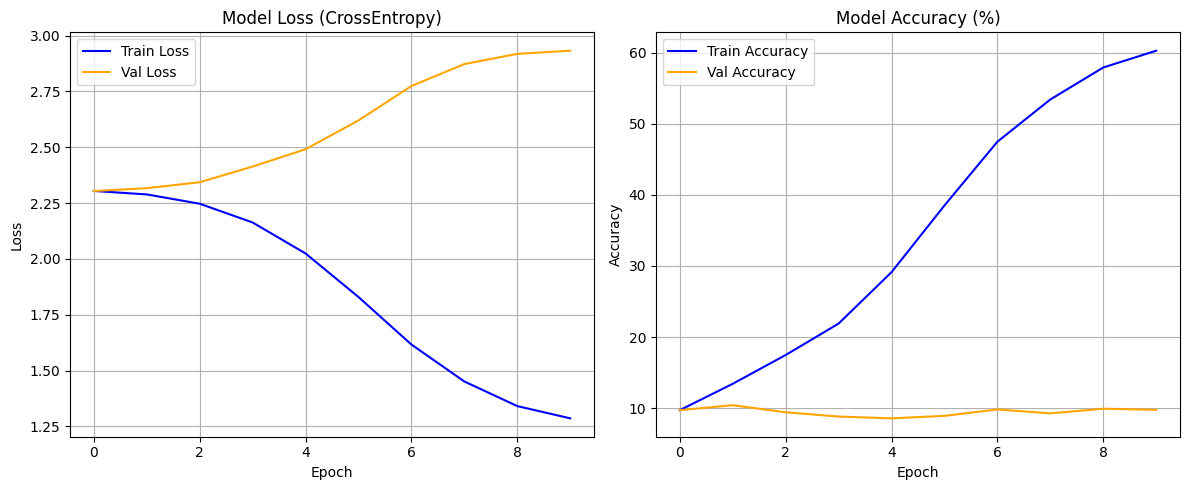

In [17]:
# Plotting Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss Plot
ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Model Loss (CrossEntropy)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Plot
ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
ax2.plot(history['val_acc'], label='Val Accuracy', color='orange')
ax2.set_title('Model Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 5. Evaluate the model on the test set

In [18]:
model.eval()

print("--- Final Test Evaluation ---")
# with torch.no_grad():          # The classic choice
with torch.inference_mode():     # The new standard
    test_outputs = model(x_test_tensor.to(device))
    test_preds = torch.argmax(test_outputs, dim=1)
    final_acc = (test_preds.cpu() == y_test_tensor).sum().item() / test_size
    print(f"Final Test Accuracy: {final_acc*100:.2f}%")

--- Final Test Evaluation ---
Final Test Accuracy: 9.35%


# 6. Inference

In [19]:
# Predict one sample (be careful with the input tensor's shape)
single_example = x_test_tensor[0].unsqueeze(0).to(device)

model.eval()
# with torch.no_grad():          # The classic choice
with torch.inference_mode():     # The new standard
    single_pred = model(single_example)
    predicted_class = torch.argmax(single_pred, dim=1).item()
    print(f"Single Example Prediction: Class {predicted_class} (True: {y_test_tensor[0].item()})")

Single Example Prediction: Class 6 (True: 7)


In [20]:
# Predict a batch of samples
batch_examples = x_test_tensor[:5].to(device)

# with torch.no_grad():          # The classic choice
with torch.inference_mode():     # The new standard
    batch_preds = model(batch_examples)
    predicted_classes = torch.argmax(batch_preds, dim=1).cpu().numpy()
    print(f"Batch Predictions: {predicted_classes} (True: {y_test_tensor[:5].numpy()})")

Batch Predictions: [6 2 8 2 7] (True: [7 6 3 8 0])
